In [1]:
pip install pandas numpy matplotlib seaborn fitparse requests

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


# Summer 2019 Personal Fitness Data Report

## 1. Introduction

### 1.1. Dataset

In this report, we are working with a client's fitness data, collected from multiple devices, and multiple workout types, from Jul 8th to Oct 3rd, 2019. The dataset has over 40,000 rows of data. Beyond basic session metadata, the dataset provides continuous heart rate, and 3D spatial coordinates (latitude, longitude, and enhanced barometric altitude).

In this GitHub repository, you can find the complete dataset as below:

- **`strava.csv`**: The primary dataset containing compiled workout data from all devices.
- **`extra.tar.gz`**: The compressed file containing raw, multi-sensor `.fit` activity logs exported from wearable hardware.
- **`extra_data/extra`**: The extracted directory containing high-precision raw data streams.

From this dataset, we will take a look at our client's workout habits, and investigate what factors might help elevate our client's heart rate during workout. Acording to [American Heart Association](https://www.heart.org/en/healthy-living/ exercise-and-physical-activity/fitness-basics/aha-recs-for-physical-activity-in-adults), elevating your heart rate to the targeted zone during workout, and accumulating enough weekly minutes of workout at moderate and vigorous level can help you hink, feel and sleep better and perform daily tasks more easily. Hence, we are interested in workout metrics such as duration and heart rate. 

### 1.2. Reflection on Rule et al's ten rules for computational analyses

In this mini-project, we follow most of Rule et al's ten rules of writing and sharing Jupyter Notebook. Here's how:

- Rule 1: **Tell a story for an audience** Closely followed. We begin the notebook with an introduction of our topic, our dataset, and what we are looking for. Followed with our steps description: what we did, why we did it, and how steps are connected. The ending sections are for interpreting the results and proposed next steps.
- Rule 2: **Document the process, not just the results** Followed. We push various commit to GitHub main branch along the way. Markdown cells and comments are added along the way to keep track of our intention and thought process.
- Rule 3: **Use cell divisions to make steps clear** Followed. Before a block of code, there is usually a markdown cell explaining what the code is for, what it is doing, or what it is aiming to. If needed, we also add another markdown cell following that code to explain what the code's output means.
- Rule 4: **Modularize code** Not followed. This is our favorite rule. However, we do not re-use code that much in this notebook. Our code is not too long either. Hence, only a couple of functions are created.
- Rule 5: **Record dependencies** Followed. At the top of this notebook, you will find a pip install command that includes the libraries and modules you need to run this notebook.
- Rule 6: **Use version control** Partially followed. We push commits to GitHub main branch, but we do not convert to .py before committing changes.
- Rule 7: **Build a pipeline** Followed. We have to restart kernel and re-run all cells frequently to make sure the dataframes stay the way we want them to be. Especially when we repeatedly update their columns' values. The key variable, which is our main dataframe df, is declared near the top of the notebook.
- Rule 8: **Share and explain your data** Followed. We make all the dataset public for this mini-project, along with our notebook.
- Rule 9: **Design your notebook to be read, run, and explored** Partially followed. Since the whole repository is public, anyone can read, run, or fork it. However, we do not go to open source license to grant permission, or use Nbviewer, Binder, Docker, ipywidgets... to offer further options to future users.
- Rule 10: **Advocate for open research** Not followed. Due to the limit scope of this mini-project, we did not ask others to read, run, or explore this notebook before making it public.

## 2. Data import and preparation

### 2.1. Main data file: import and first look

In this section, we will import our main data file `strava.csv`. We will only take a quick look at this data file and then explore the extra data, before performing further data preparation.

First, let's import Python libraries necessary for our data analysics.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Now we have our library. Let's import our file and take a look.

In [4]:
df = pd.read_csv('strava.csv')
pd.set_option('display.max_columns', None)
df.head()

,Air Power,Cadence,Form Power,Ground Time,Leg Spring Stiffness,Power,Vertical Oscillation,altitude,cadence,datafile,distance,enhanced_altitude,enhanced_speed,fractional_cadence,heart_rate,position_lat,position_long,speed,timestamp,unknown_87,unknown_88,unknown_90
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,activities/2675855419.fit.gz,0.00,NaN,0.000,0.0,68.0,NaN,NaN,0.0,2019-07-08 21:04:03,0.0,300.0,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,activities/2675855419.fit.gz,0.00,NaN,0.000,0.0,68.0,NaN,NaN,0.0,2019-07-08 21:04:04,0.0,300.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.0,activities/2675855419.fit.gz,1.32,NaN,1.316,0.0,71.0,NaN,NaN,1316.0,2019-07-08 21:04:07,0.0,300.0,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3747.0,77.0,activities/2675855419.fit.gz,12.19,249.4,1.866,0.0,77.0,504432050.0,-999063637.0,1866.0,2019-07-08 21:04:14,0.0,100.0,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3798.0,77.0,activities/2675855419.fit.gz,14.08,259.6,1.894,0.0,80.0,504432492.0,-999064534.0,1894.0,2019-07-08 21:04:15,0.0,100.0,NaN


That's a lot of missing values. We will look into them later. Now let's see what info this dataset has to offer.

In [5]:
df.columns

Index(['Air Power', 'Cadence', 'Form Power', 'Ground Time',
       'Leg Spring Stiffness', 'Power', 'Vertical Oscillation', 'altitude',
       'cadence', 'datafile', 'distance', 'enhanced_altitude',
       'enhanced_speed', 'fractional_cadence', 'heart_rate', 'position_lat',
       'position_long', 'speed', 'timestamp', 'unknown_87', 'unknown_88',
       'unknown_90'],
      dtype='str')

There're a lot of insights we can explore with these values. In this notebook, we are interested in:
- 'timestamp': necessary to analyze workout habits and durations
- 'heart_rate': important workout metric
- 'cadence' and 'Cadence': related to movement frequency recorded during workout
- 'altitude', 'enhanced_altitude', 'position_lat', 'position_long': spatial coordinates recorded during workout

We will further perform data cleaning and preparation for these values in later sections.

For now, let's take a look at the range of our data:

In [6]:
df.describe()

,Air Power,Cadence,Form Power,Ground Time,Leg Spring Stiffness,Power,Vertical Oscillation,altitude,cadence,distance,enhanced_altitude,enhanced_speed,fractional_cadence,heart_rate,position_lat,position_long,speed,unknown_87,unknown_88,unknown_90
count,17842.000000,17847.000000,17842.000000,17847.000000,17842.000000,17847.000000,17847.000000,14905.000000,40627.000000,40649.000000,40598.000000,40639.000000,40627.000000,38355.000000,4.045700e+04,4.045700e+04,14928.000000,40627.0,38355.000000,18618.000000
mean,1.872100,77.726565,99.485932,325.934107,13.138571,301.459797,6.458074,3846.184368,72.781254,4097.140051,271.346027,3.037084,0.070138,134.680094,5.045408e+08,-9.995175e+08,2067.483856,0.0,298.513883,-1.067354
std,2.777476,9.202077,13.866222,71.773687,2.039567,48.540552,1.135497,134.262498,17.743728,5827.964663,25.035768,1.959805,0.173639,18.713782,1.690905e+05,1.376341e+06,527.173476,0.0,17.176218,2.820492
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3555.000000,0.000000,0.000000,209.000000,0.000000,0.000000,56.000000,5.039868e+08,-1.005696e+09,0.000000,0.0,100.000000,-13.000000
25%,1.000000,78.000000,97.000000,308.000000,13.000000,283.000000,6.125000,3768.000000,74.000000,1117.970000,252.800000,2.109000,0.000000,121.000000,5.044397e+08,-9.993986e+08,1782.000000,0.0,300.000000,-3.000000
50%,1.000000,79.000000,101.000000,326.000000,13.375000,303.000000,6.500000,3829.000000,78.000000,2430.500000,269.200000,2.445000,0.000000,136.000000,5.045116e+08,-9.992608e+08,2071.000000,0.0,300.000000,0.000000
75%,2.000000,80.000000,105.000000,340.000000,13.750000,326.000000,7.000000,3912.000000,80.000000,4403.730000,291.200000,2.809000,0.000000,148.000000,5.046159e+08,-9.990579e+08,2370.000000,0.0,300.000000,0.000000
max,48.000000,88.000000,125.000000,1732.000000,16.875000,462.000000,12.500000,5043.000000,118.000000,39007.120000,508.600000,15.349000,0.500000,183.000000,5.089272e+08,-9.921938e+08,7744.000000,0.0,300.000000,6.000000


Nothing raises immediate questions. How about data type of each column?

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40649 entries, 0 to 40648
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Air Power             17842 non-null  float64
 1   Cadence               17847 non-null  float64
 2   Form Power            17842 non-null  float64
 3   Ground Time           17847 non-null  float64
 4   Leg Spring Stiffness  17842 non-null  float64
 5   Power                 17847 non-null  float64
 6   Vertical Oscillation  17847 non-null  float64
 7   altitude              14905 non-null  float64
 8   cadence               40627 non-null  float64
 9   datafile              40649 non-null  str    
 10  distance              40649 non-null  float64
 11  enhanced_altitude     40598 non-null  float64
 12  enhanced_speed        40639 non-null  float64
 13  fractional_cadence    40627 non-null  float64
 14  heart_rate            38355 non-null  float64
 15  position_lat          40457 no

We notice that timestamp is in string. Let's create another timestamp_dt column in datetime type for our later analysis:

In [8]:
df['timestamp_dt'] = pd.to_datetime(df['timestamp'], unit='s')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40649 entries, 0 to 40648
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Air Power             17842 non-null  float64       
 1   Cadence               17847 non-null  float64       
 2   Form Power            17842 non-null  float64       
 3   Ground Time           17847 non-null  float64       
 4   Leg Spring Stiffness  17842 non-null  float64       
 5   Power                 17847 non-null  float64       
 6   Vertical Oscillation  17847 non-null  float64       
 7   altitude              14905 non-null  float64       
 8   cadence               40627 non-null  float64       
 9   datafile              40649 non-null  str           
 10  distance              40649 non-null  float64       
 11  enhanced_altitude     40598 non-null  float64       
 12  enhanced_speed        40639 non-null  float64       
 13  fractional_cadence    40627

Let's check our extra data.

### 2.2. Extra data exploration

In this section, we are looking into extra data, our compressed folder. First, we have to extract it. The below code block also creates a list of paths for each file in the extracted folder.

In [9]:
# access extra data in .tar.gz folder
import io
import requests
import tarfile

url = "https://github.com/vandao288/strava_data_report/raw/main/extra.tar.gz"

response = requests.get(url)
# Open the downloaded stream as a gzipped tar archive ('r:gz')
with tarfile.open(fileobj=io.BytesIO(response.content), mode="r:gz") as tar:
    # List all file names in the archive
    #print(tar.getnames())
    file_paths = tar.getnames()
    print(file_paths)
    # Extract to a local directory
    tar.extractall("./extra_data")

['extra', 'extra/2688518063.fit', 'extra/2694503189.fit', 'extra/2878165145.fit', 'extra/2934415201.fit', 'extra/2875543445.fit', 'extra/4202632408.fit', 'extra/4431076868.fit', 'extra/3220821481.fit', 'extra/2677659014.fit', 'extra/2737470737.fit', 'extra/3037049993.fit', 'extra/2725350599.fit', 'extra/4262319929.fit', 'extra/4233198342.fit', 'extra/2939549086.fit', 'extra/2694503073.fit', 'extra/4449332433.fit', 'extra/2749660320.fit', 'extra/3276319440.fit', 'extra/3573233193.fit', 'extra/4116838134.fit', 'extra/2791022871.fit', 'extra/4116832581.fit', 'extra/2700298434.fit', 'extra/2796808375.fit', 'extra/4182662451.fit', 'extra/2711850942.fit', 'extra/4223086640.fit', 'extra/2912139332.fit', 'extra/3589053594.fit', 'extra/2829934608.fit', 'extra/3094198881.fit', 'extra/3747633909.fit', 'extra/3744072620.fit', 'extra/4380955548.fit', 'extra/4171121567.fit', 'extra/2749724556.fit', 'extra/4151263436.fit', 'extra/3964368444.fit', 'extra/3456057777.fit', 'extra/3790627836.fit', 'extra

How many files in this extra data folder?

In [10]:
len(file_paths)

200

The first path was for the 'extra' folder. Hence, there are 199 files in this extra data. Let's read the one of them.

In [11]:
from fitparse import FitFile

file0 = file_paths[1]
full_file_path = f'./extra_data/{file0}'
fitfile = FitFile(full_file_path)
records = fitfile.get_messages('record')
for record in records:
    for data in record:
        print(data)

altitude: 258.0 [m]
cadence: 74 [rpm]
distance: 1.27 [m]
enhanced_altitude: 258.0 [m]
enhanced_speed: 1.885 [m/s]
fractional_cadence: 0.5 [rpm]
heart_rate: 103 [bpm]
position_lat: 504427594 [semicircles]
position_long: -998947981 [semicircles]
speed: 1.885 [m/s]
timestamp: 2019-07-14 17:20:28
unknown_87: 0
unknown_88: 300
altitude: 257.79999999999995 [m]
cadence: 74 [rpm]
distance: 2.21 [m]
enhanced_altitude: 257.79999999999995 [m]
enhanced_speed: 1.959 [m/s]
fractional_cadence: 0.5 [rpm]
heart_rate: 104 [bpm]
position_lat: 504427557 [semicircles]
position_long: -998947840 [semicircles]
speed: 1.959 [m/s]
timestamp: 2019-07-14 17:20:29
unknown_87: 0
unknown_88: 300
altitude: 257.4 [m]
cadence: 74 [rpm]
distance: 3.5 [m]
enhanced_altitude: 257.4 [m]
enhanced_speed: 1.81 [m/s]
fractional_cadence: 0.5 [rpm]
heart_rate: 104 [bpm]
position_lat: 504427501 [semicircles]
position_long: -998947669 [semicircles]
speed: 1.81 [m/s]
timestamp: 2019-07-14 17:20:30
unknown_87: 0
unknown_88: 300
altit

Most of the information we need are already imported into our main dataframe. In our analysis, we do not necessarily dive deep into these .fit files. By updating file_paths[] index in the above code block, we are still able to look into our extra data to check specific feature units, which metrics are provided, or some device information. These info will be incorporated in later works. For now, let's go back to our main dataframe.

### 2.3. Unified cadence

One of the features we are interested in is cadence. We notice there are 'cadence' and 'Cadence' columns in our main dataframe. Eventually, we will need to come down to one unified cadence value for our data analysis. The difference between these two are:
- cadence: the sensor measurement of movement frequency recorded over time during your activity.
- Cadence: refers to hardware metadata, device naming, or a third-party software component rather than the active measurement.

However, as our dataframe's head showed us before, there could be a lot of missing data in these columns. Let's take a look:

In [12]:
df.isna().sum()

Air Power               22807
Cadence                 22802
Form Power              22807
Ground Time             22802
Leg Spring Stiffness    22807
Power                   22802
Vertical Oscillation    22802
altitude                25744
cadence                    22
datafile                    0
distance                    0
enhanced_altitude          51
enhanced_speed             10
fractional_cadence         22
heart_rate               2294
position_lat              192
position_long             192
speed                   25721
timestamp                   0
unknown_87                 22
unknown_88               2294
unknown_90              22031
timestamp_dt                0
dtype: int64

In [13]:
df.shape

(40649, 23)

Out of 40,649 rows of our dataframe, there are 22,802 rows of missing data in 'Cadence'. Meanwhile, there are only 22 missing data in 'cadence'. Looks like when it comes to cadence measurement, our client has a reliable device sensor. Since 'cadence' is measured by device directly, instead of a third party, we will prioritize 'cadence' over 'Cadence' anyway. 

However, cadence sometimes can record single-foot movements, instead of double-foot movements, which is why we see some cadence values that are half of the other cadence values. For example, if one source records 80 cadence and the other records 40 cadence, it could be due to one source counting each foot strike (double) and the other counting each individual foot strike (single). Let's create a new column named scaled_cadence that will scale the cadence values accordingly: double the cadence values if Cadence is around double values of cadence.

In [14]:
is_half = (df['Cadence'] / df['cadence']).between(1.8, 2.2)
df['cadence_scaled'] = np.where(is_half, df['cadence'] * 2, df['cadence'])

We will create a unified cadence column that will prioritize Cadence if it is present, otherwise it will use scaled_cadence if it is present. Then fill N/A values with 0 for unified cadence. There should be only 22 rows of N/A values before fillna.

In [15]:
df['cadence_unified'] = df['Cadence'].fillna(df['cadence_scaled'])
df['cadence_unified'] = df['cadence_unified'].fillna(0)
df.sample(5)

,Air Power,Cadence,Form Power,Ground Time,Leg Spring Stiffness,Power,Vertical Oscillation,altitude,cadence,datafile,distance,enhanced_altitude,enhanced_speed,fractional_cadence,heart_rate,position_lat,position_long,speed,timestamp,unknown_87,unknown_88,unknown_90,timestamp_dt,cadence_scaled,cadence_unified
17520,1.0,77.0,107.0,314.0,13.125,291.0,7.500,NaN,77.0,activities/2791022871.fit.gz,1892.10,269.2,2.622,0.0,148.0,504528318.0,-999252868.0,NaN,2019-08-18 20:54:18,0.0,300.0,0.0,2019-08-18 20:54:18,77.0,77.0
1041,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3912.0,74.0,activities/2682705331.fit.gz,4906.59,282.4,1.885,0.0,114.0,504553106.0,-999428531.0,1885.0,2019-07-12 22:06:41,0.0,300.0,NaN,2019-07-12 22:06:41,74.0,74.0
20504,1.0,77.0,96.0,370.0,14.000,247.0,5.625,NaN,77.0,activities/2796808375.fit.gz,1305.98,238.0,1.997,0.0,138.0,504437687.0,-998683682.0,NaN,2019-08-20 20:43:36,0.0,300.0,-10.0,2019-08-20 20:43:36,77.0,77.0
9204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3973.0,71.0,activities/2729896401.fit.gz,461.00,294.6,1.577,0.5,97.0,504585663.0,-999349037.0,1577.0,2019-07-29 11:52:04,0.0,300.0,NaN,2019-07-29 11:52:04,71.0,71.0
5547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3925.0,78.0,activities/2705646131.fit.gz,1110.08,285.0,2.211,0.0,113.0,504440122.0,-999221837.0,2211.0,2019-07-20 21:36:39,0.0,300.0,NaN,2019-07-20 21:36:39,78.0,78.0


Let's check the range of our cadence_unified value.

In [16]:
df['cadence_unified'].describe()

count    40649.000000
mean        72.729883
std         17.835318
min          0.000000
25%         74.000000
50%         78.000000
75%         80.000000
max        118.000000
Name: cadence_unified, dtype: float64

Next, we will clean up 'heart_rate' column.

### 2.4. Heart rate column clean up

Let's look at heart_rate range again.

In [17]:
df.heart_rate.describe()

count    38355.000000
mean       134.680094
std         18.713782
min         56.000000
25%        121.000000
50%        136.000000
75%        148.000000
max        183.000000
Name: heart_rate, dtype: float64

The heart_rate range is from 56 to 183 bpm, which is reasonable. Let's see if there is any missing data:

In [18]:
df.isna().sum()

Air Power               22807
Cadence                 22802
Form Power              22807
Ground Time             22802
Leg Spring Stiffness    22807
Power                   22802
Vertical Oscillation    22802
altitude                25744
cadence                    22
datafile                    0
distance                    0
enhanced_altitude          51
enhanced_speed             10
fractional_cadence         22
heart_rate               2294
position_lat              192
position_long             192
speed                   25721
timestamp                   0
unknown_87                 22
unknown_88               2294
unknown_90              22031
timestamp_dt                0
cadence_scaled             22
cadence_unified             0
dtype: int64

There are 2,294 rows of missing data for heart_rate, out of over 40,000 rows of data. Let's drop these rows.

In [19]:
hr_cleaned = df[df['heart_rate'].notna()]
hr_cleaned.describe()

,Air Power,Cadence,Form Power,Ground Time,Leg Spring Stiffness,Power,Vertical Oscillation,altitude,cadence,distance,enhanced_altitude,enhanced_speed,fractional_cadence,heart_rate,position_lat,position_long,speed,unknown_87,unknown_88,unknown_90,timestamp_dt,cadence_scaled,cadence_unified
count,17842.000000,17847.000000,17842.000000,17847.000000,17842.000000,17847.000000,17847.000000,14905.000000,38344.000000,38355.000000,38304.000000,38345.000000,38344.000000,38355.000000,3.816300e+04,3.816300e+04,14928.000000,38344.0,38355.000000,18618.000000,38355,38344.000000,38355.000000
mean,1.872100,77.726565,99.485932,325.934107,13.138571,301.459797,6.458074,3846.184368,73.867672,3641.014081,272.072144,2.854132,0.074314,134.680094,5.045379e+08,-9.995210e+08,2067.483856,0.0,298.513883,-1.067354,2019-08-16 12:43:20.065988,73.867672,73.833790
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3555.000000,0.000000,0.000000,209.000000,0.000000,0.000000,56.000000,5.039995e+08,-1.005696e+09,0.000000,0.0,100.000000,-13.000000,2019-07-08 21:04:03,0.000000,0.000000
25%,1.000000,78.000000,97.000000,308.000000,13.000000,283.000000,6.125000,3768.000000,75.000000,1083.475000,253.400000,2.090000,0.000000,121.000000,5.044413e+08,-9.993970e+08,1782.000000,0.0,300.000000,-3.000000,2019-07-30 19:39:24,75.000000,75.000000
50%,1.000000,79.000000,101.000000,326.000000,13.375000,303.000000,6.500000,3829.000000,78.000000,2333.480000,270.400000,2.417000,0.000000,136.000000,5.045103e+08,-9.992602e+08,2071.000000,0.0,300.000000,0.000000,2019-08-20 19:41:48,78.000000,78.000000
75%,2.000000,80.000000,105.000000,340.000000,13.750000,326.000000,7.000000,3912.000000,80.000000,4199.930000,292.000000,2.734000,0.000000,148.000000,5.046140e+08,-9.990522e+08,2370.000000,0.0,300.000000,0.000000,2019-08-23 02:04:57.500000,80.000000,80.000000
max,48.000000,88.000000,125.000000,1732.000000,16.875000,462.000000,12.500000,5043.000000,117.000000,38652.590000,508.600000,15.237000,0.500000,183.000000,5.089272e+08,-9.921938e+08,7744.000000,0.0,300.000000,6.000000,2019-10-03 23:05:05,117.000000,117.000000
std,2.777476,9.202077,13.866222,71.773687,2.039567,48.540552,1.135497,134.262498,16.084253,4931.337724,25.247229,1.745879,0.177863,18.713782,1.538676e+05,1.409369e+06,527.173476,0.0,17.176218,2.820492,NaN,16.084253,16.149888


We will use this hr_cleaned dataframe in our data analysis.

### 2.5. Geographic coordinates preparation

In this section, we will clean and prepare coordinates data. 

#### 2.5.1. Unified altitude

We noticed there are 2 columns regarding altitude in our dataset: 'altitude' and 'enhanced_altitude'. While both track altitude during workout, 'enhanced_altitude' records higher precision, down to fraction of a meter, while 'altitude' rounds to the nearest meter. For this reason, we will prioritize 'enhanced_altitude' as our unified altitude. 'enhanced_altitude' also has way more records than 'altitude': 'enhanced_altitude' has only 51 missing values, while 'altitude' has 25,744 missing values out of 40,649 rows of data.

In [20]:
df['unified_altitude'] = df['enhanced_altitude'].fillna(df['altitude'])

#### 2.5.2. Dataframe preparation for heart rate vs coordinates analysis

Let's create another dataframe for just heart rate and geographic coordinates:

In [21]:
df_selected = df[['heart_rate', 'unified_altitude', 'position_lat', 'position_long']]
df_selected.head()

,heart_rate,unified_altitude,position_lat,position_long
0,68.0,NaN,NaN,NaN
1,68.0,NaN,NaN,NaN
2,71.0,NaN,NaN,NaN
3,77.0,249.4,504432050.0,-999063637.0
4,80.0,259.6,504432492.0,-999064534.0


We want to drop all the missing values in this dataframe:

In [22]:
df_selected = df_selected.dropna()
df_selected.shape

(38163, 4)

We still have 38,163 rows of data. That looks good. Let's take a look at our data range:

In [23]:
df_selected.describe()

,heart_rate,unified_altitude,position_lat,position_long
count,38163.000000,38163.000000,3.816300e+04,3.816300e+04
mean,134.774415,272.084606,5.045379e+08,-9.995210e+08
std,18.670995,25.199153,1.538676e+05,1.409369e+06
min,56.000000,209.000000,5.039995e+08,-1.005696e+09
25%,121.000000,253.400000,5.044413e+08,-9.993970e+08
50%,137.000000,270.400000,5.045103e+08,-9.992602e+08
75%,148.000000,292.000000,5.046140e+08,-9.990522e+08
max,183.000000,508.600000,5.089272e+08,-9.921938e+08


The latitude and longitude ranges do not look right. We will work on them in the next steps.

#### 2.5.3. Latitude and longtitude preparation

This data source is trying to capture longitude and latitude the maximum precision possible in an unsigned integer. Hence, we have to convert latitude and longitude to traditional decimal format. This can be done by multiplying by folowing formula:

In [24]:
# Convert longitude and latitude to decimal degrees
df_selected['position_lat'] = df_selected['position_lat'] * (180 / 2**31)
df_selected['position_long'] = df_selected['position_long'] * (180 / 2**31)

One more thing, we need to apply Mercantor projection to convert latitude from curved Earth surface to flat map surface.

In [25]:
# Convert global coordinates to flat coordinates using Mercantor projection

def lat2y(a):
    return 180.0/np.pi*np.log(np.tan(np.pi/4.0+a*(np.pi/180.0)/2.0))

df_selected["position_lat"]=df_selected["position_lat"].apply(lat2y)

Now let's check our data range again:

In [26]:
df_selected.describe()

,heart_rate,unified_altitude,position_lat,position_long
count,38163.000000,38163.000000,38163.000000,38163.000000
mean,134.774415,272.084606,46.752828,-83.778882
std,18.670995,25.199153,0.017438,0.118132
min,56.000000,209.000000,46.691845,-84.296446
25%,121.000000,253.400000,46.741880,-83.768493
50%,137.000000,270.400000,46.749698,-83.757025
75%,148.000000,292.000000,46.761455,-83.739591
max,183.000000,508.600000,47.251630,-83.164726


That looks good. Now we are ready for data analysis.

## 3. Data analysis and visualization

### 3.1. Break down to workout sessions

In our analysis, we are interested in workout patterns and average heart rate during workout session. In order to track these patterns, we need to break down our data set into workout sessions. 

We will use hr_cleaned dataframe created above for this analysis. First, we need to sort data rows ascending by time stamp.

In [27]:
hr_sorted = hr_cleaned.sort_values(by='timestamp_dt').drop_duplicates(subset=['timestamp_dt'])
hr_sorted.head()

,Air Power,Cadence,Form Power,Ground Time,Leg Spring Stiffness,Power,Vertical Oscillation,altitude,cadence,datafile,distance,enhanced_altitude,enhanced_speed,fractional_cadence,heart_rate,position_lat,position_long,speed,timestamp,unknown_87,unknown_88,unknown_90,timestamp_dt,cadence_scaled,cadence_unified
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,activities/2675855419.fit.gz,0.00,NaN,0.000,0.0,68.0,NaN,NaN,0.0,2019-07-08 21:04:03,0.0,300.0,NaN,2019-07-08 21:04:03,0.0,0.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,activities/2675855419.fit.gz,0.00,NaN,0.000,0.0,68.0,NaN,NaN,0.0,2019-07-08 21:04:04,0.0,300.0,NaN,2019-07-08 21:04:04,0.0,0.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.0,activities/2675855419.fit.gz,1.32,NaN,1.316,0.0,71.0,NaN,NaN,1316.0,2019-07-08 21:04:07,0.0,300.0,NaN,2019-07-08 21:04:07,54.0,54.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3747.0,77.0,activities/2675855419.fit.gz,12.19,249.4,1.866,0.0,77.0,504432050.0,-999063637.0,1866.0,2019-07-08 21:04:14,0.0,100.0,NaN,2019-07-08 21:04:14,77.0,77.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3798.0,77.0,activities/2675855419.fit.gz,14.08,259.6,1.894,0.0,80.0,504432492.0,-999064534.0,1894.0,2019-07-08 21:04:15,0.0,100.0,NaN,2019-07-08 21:04:15,77.0,77.0


In our definition, if a workout record is more than 30 minutes away from the last record, it is a new workout session. We will record workout session start time, end time, average heart rate and cadence in each workout session using the code block below.

In [28]:
time_deltas = hr_sorted['timestamp_dt'].diff().dt.total_seconds()
hr_sorted['session_id'] = (time_deltas >= 1800).cumsum()
workout_summary = hr_sorted.groupby('session_id').agg(
    start_time=('timestamp_dt', 'min'),
    end_time=('timestamp_dt', 'max'),
    avg_heart_rate=('heart_rate', 'mean'),
    avg_cadence=('cadence_unified', 'mean')
).reset_index(drop=True)

workout_summary.head()

,start_time,end_time,avg_heart_rate,avg_cadence
0,2019-07-08 21:04:03,2019-07-08 21:23:55,118.337398,74.406504
1,2019-07-10 23:18:00,2019-07-10 23:37:20,130.123596,79.314607
2,2019-07-12 21:27:11,2019-07-12 22:30:17,117.687157,74.135016
3,2019-07-14 17:20:28,2019-07-14 18:38:22,110.975460,74.465381
4,2019-07-14 20:45:07,2019-07-14 21:04:51,123.819398,79.705686


We can easily calculate workout duration from start_time and end_time.

In [29]:
workout_summary['duration(m)'] = (workout_summary['end_time'] - workout_summary['start_time']).dt.total_seconds() / 60  # duration in minutes
workout_summary.head()

,start_time,end_time,avg_heart_rate,avg_cadence,duration(m)
0,2019-07-08 21:04:03,2019-07-08 21:23:55,118.337398,74.406504,19.866667
1,2019-07-10 23:18:00,2019-07-10 23:37:20,130.123596,79.314607,19.333333
2,2019-07-12 21:27:11,2019-07-12 22:30:17,117.687157,74.135016,63.100000
3,2019-07-14 17:20:28,2019-07-14 18:38:22,110.975460,74.465381,77.900000
4,2019-07-14 20:45:07,2019-07-14 21:04:51,123.819398,79.705686,19.733333


Let's check the range of our data see if there's any anomaly.

In [30]:
workout_summary.describe()

,start_time,end_time,avg_heart_rate,avg_cadence,duration(m)
count,49,49,49.000000,49.000000,49.000000
mean,2019-08-10 05:51:51.142857,2019-08-10 06:31:36.775510,129.029087,73.048548,39.760544
min,2019-07-08 21:04:03,2019-07-08 21:23:55,99.187675,14.988456,7.466667
25%,2019-07-23 00:49:07,2019-07-23 01:14:46,118.566787,72.811688,19.333333
50%,2019-08-05 21:45:11,2019-08-05 22:03:00,128.251504,75.614407,33.216667
75%,2019-08-21 01:15:54,2019-08-21 01:49:07,138.466667,77.936271,49.150000
max,2019-10-03 21:30:03,2019-10-03 23:05:05,163.401752,80.532511,95.033333
std,NaN,NaN,14.553232,10.355174,24.769623


Our data range looks good so far. We can go ahead and analyze and visualize this data set.

### 3.2. Average heart rate vs cadence scatter plot

Now we are ready to see the relationship between average cadence and heart rate in each workout session. A scatter plot is the best option to visualize this relationship.

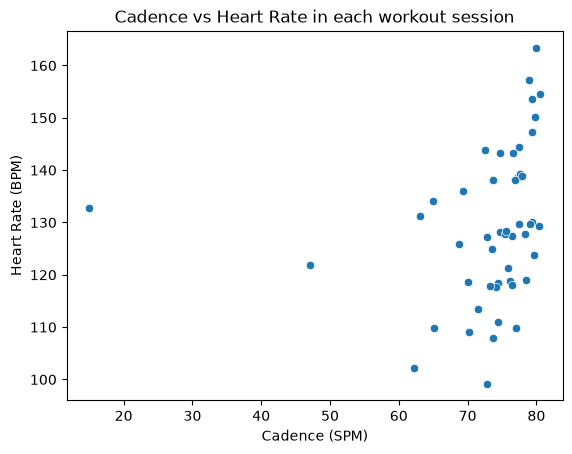

In [31]:
sns.scatterplot(data=workout_summary, x="avg_cadence", y="avg_heart_rate")
plt.title("Cadence vs Heart Rate in each workout session")
plt.xlabel("Cadence (SPM)")
plt.ylabel("Heart Rate (BPM)")
plt.show()

The two outlier data points on the left take the most space on our chart. Let's remove two outliers on the far left so we have more room to observe the relationship better. This time, we will add an estimated linear trend line.

In [32]:
workout_summary_cleaned = workout_summary[workout_summary['avg_cadence'] > 50]

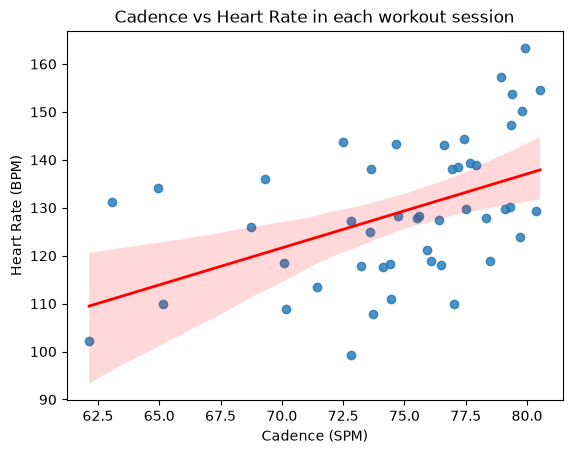

In [33]:
sns.regplot(
    data=workout_summary_cleaned,
    x='avg_cadence',
    y='avg_heart_rate',
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Cadence vs Heart Rate in each workout session')
plt.xlabel("Cadence (SPM)")
plt.ylabel("Heart Rate (BPM)")
plt.show()

There is a weak positive relationship between average heart rate and cadence in workout sessions. Generally, higher movement usually associates with higher heart rate. However, it is not always the case.

### 3.3. Workout frequency heatmap

Next, we will see how many times our client exercised each day. Then create a heat map for it. We are also interested in which days of the week our client tended to work out the most consistently. Below we create a new dataframe called daily_session_count to track daily number of workout sessions for our client.

In [34]:
workout_summary['date'] = workout_summary['start_time'].dt.date
workout_summary['day_of_week'] = workout_summary['start_time'].dt.day_name()
workout_summary.head()

,start_time,end_time,avg_heart_rate,avg_cadence,duration(m),date,day_of_week
0,2019-07-08 21:04:03,2019-07-08 21:23:55,118.337398,74.406504,19.866667,2019-07-08,Monday
1,2019-07-10 23:18:00,2019-07-10 23:37:20,130.123596,79.314607,19.333333,2019-07-10,Wednesday
2,2019-07-12 21:27:11,2019-07-12 22:30:17,117.687157,74.135016,63.100000,2019-07-12,Friday
3,2019-07-14 17:20:28,2019-07-14 18:38:22,110.975460,74.465381,77.900000,2019-07-14,Sunday
4,2019-07-14 20:45:07,2019-07-14 21:04:51,123.819398,79.705686,19.733333,2019-07-14,Sunday


In [35]:
daily_session_count = workout_summary.groupby('date').size().reset_index(name='daily_session_count')
daily_session_count.head()

,date,daily_session_count
0,2019-07-08,1
1,2019-07-10,1
2,2019-07-12,1
3,2019-07-14,2
4,2019-07-16,1


In [36]:
daily_session_count.describe()

,daily_session_count
count,45.000000
mean,1.088889
std,0.287799
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,2.000000


Our client excercised maximum 2 times a day. Next, we will create a heat map similar to GitHub commit heat map. 

First, we will fill in the full date range of our data set. On the day with no workout, we set that day's session count to be 0.

In [37]:
full_date_range = pd.date_range(start=df['timestamp_dt'].min(), end=df['timestamp_dt'].max())

In [38]:
df_calendar = pd.DataFrame({'date': full_date_range.date})
session_map = daily_session_count.set_index('date')['daily_session_count']
df_calendar['session_count'] = df_calendar['date'].map(session_map).fillna(0)  
df_calendar.head()

,date,session_count
0,2019-07-08,1.0
1,2019-07-09,0.0
2,2019-07-10,1.0
3,2019-07-11,0.0
4,2019-07-12,1.0


In [39]:
df_calendar['session_count'] = df_calendar['session_count'].astype(int)
df_calendar.head()

,date,session_count
0,2019-07-08,1
1,2019-07-09,0
2,2019-07-10,1
3,2019-07-11,0
4,2019-07-12,1


The session count values look good. Now we need to note down day of week (Monday, Tuesday...) to bring in our data visualization later.

In [40]:
df_calendar['datetime'] = pd.to_datetime(df_calendar['date'])
df_calendar['day_of_week'] = df_calendar['datetime'].dt.day_name()
df_calendar.head()

,date,session_count,datetime,day_of_week
0,2019-07-08,1,2019-07-08,Monday
1,2019-07-09,0,2019-07-09,Tuesday
2,2019-07-10,1,2019-07-10,Wednesday
3,2019-07-11,0,2019-07-11,Thursday
4,2019-07-12,1,2019-07-12,Friday


In [41]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

We also need to note down the week_start date to easier track weekly workout.

In [42]:
df_calendar['week_start'] = df_calendar['datetime'].dt.to_period('W-MON').dt.start_time
df_calendar.head()

,date,session_count,datetime,day_of_week,week_start
0,2019-07-08,1,2019-07-08,Monday,2019-07-02
1,2019-07-09,0,2019-07-09,Tuesday,2019-07-09
2,2019-07-10,1,2019-07-10,Wednesday,2019-07-09
3,2019-07-11,0,2019-07-11,Thursday,2019-07-09
4,2019-07-12,1,2019-07-12,Friday,2019-07-09


In [43]:
df_calendar['week_start_str'] = df_calendar['week_start'].dt.strftime('%b %d')
df_calendar.head()

,date,session_count,datetime,day_of_week,week_start,week_start_str
0,2019-07-08,1,2019-07-08,Monday,2019-07-02,Jul 02
1,2019-07-09,0,2019-07-09,Tuesday,2019-07-09,Jul 09
2,2019-07-10,1,2019-07-10,Wednesday,2019-07-09,Jul 09
3,2019-07-11,0,2019-07-11,Thursday,2019-07-09,Jul 09
4,2019-07-12,1,2019-07-12,Friday,2019-07-09,Jul 09


To create the heat map, we need to convert our dataframe into a pitvot table.

In [44]:
heatmap_matrix = (
    df_calendar.pivot_table(
        index='day_of_week',
        columns='week_start',
        values='session_count',
        aggfunc='sum',
        fill_value=0,
    )
    .reindex(day_order)
    .astype(int)
)

heatmap_matrix = heatmap_matrix.reindex(columns=sorted(heatmap_matrix.columns))
heatmap_matrix.columns = heatmap_matrix.columns.strftime('%b %d')
heatmap_matrix

week_start,Jul 02,Jul 09,Jul 16,Jul 23,Jul 30,Aug 06,Aug 13,Aug 20,Aug 27,Sep 03,Sep 10,Sep 17,Sep 24,Oct 01
day_of_week,,,,,,,,,,,,,,
Monday,1,0,1,1,1,1,0,0,0,0,1,1,0,0
Tuesday,0,0,1,1,1,1,0,2,0,0,0,0,0,0
Wednesday,0,1,1,1,1,1,1,2,1,0,0,0,1,0
Thursday,0,0,1,0,1,0,0,0,0,0,1,0,0,1
Friday,0,1,0,1,1,1,0,1,0,0,0,0,0,0
Saturday,0,0,2,1,1,1,1,1,1,0,1,0,1,0
Sunday,0,2,1,1,1,1,1,0,0,0,0,0,0,0


And now we are ready to create the heat map.

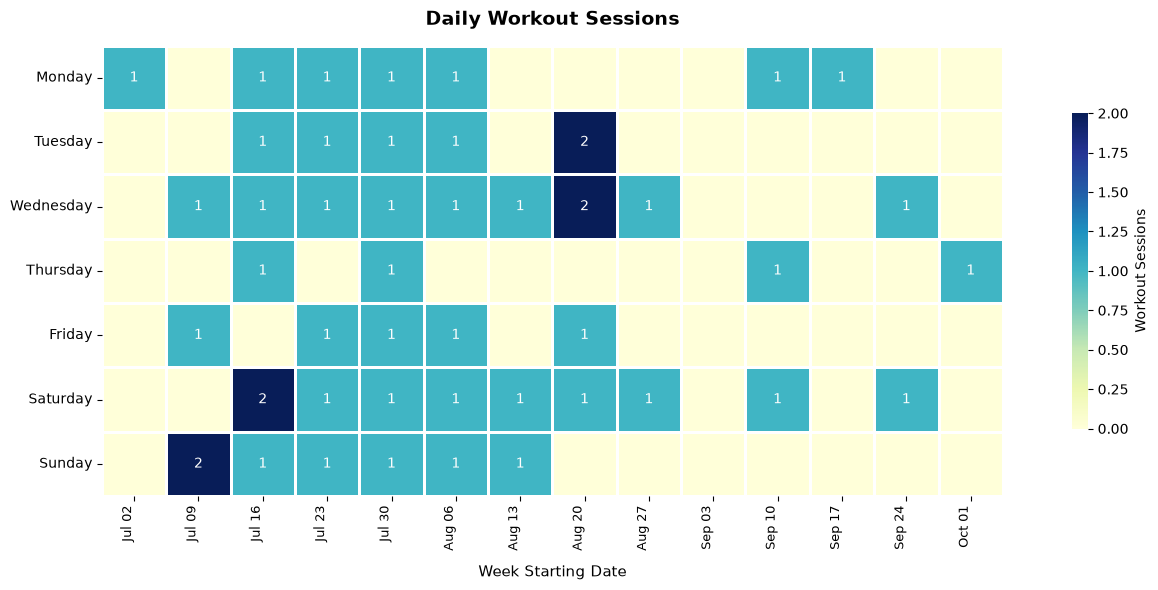

In [45]:
plt.figure(figsize=(15, 6))
ax = sns.heatmap(
    heatmap_matrix,
    cmap = 'YlGnBu',
    linewidths = 2,
    linecolor = 'white',
    square = True,
    cbar_kws = {'label': 'Workout Sessions', 'shrink': 0.7},
    annot = heatmap_matrix.map(lambda v: '' if v == 0 else str(int(v))), # skip annotation if workout session = 0
    fmt = '',
)

plt.title(
    'Daily Workout Sessions', 
    fontsize = 14, 
    pad = 15, 
    fontweight = 'bold'
)
plt.xlabel('Week Starting Date', fontsize=11, labelpad=10)
plt.ylabel('')
plt.yticks(rotation=0)
plt.xticks(rotation=90, ha='right', fontsize=9)  

plt.tight_layout()
plt.show()

Our client started their workout journey casually in the week of July 2nd, 2019 with only one workout session. However, for the next 7 weeks, they get the good habit going strong with 4 workout sessions or more almost every week. The habit slows down during the week of Aug 27th, 2019 with only 2 workout sessions. Then a whole week of Sep 3rd go on with no workout at all. Our client starts bringing back the workout habit the week after. However, the moment is not the same: the number of workout sessions drops down to 1 or 2 per week from Sep 17th forward.<br>On the day our client workout, they usually workout once. However, there are 4 days they workout twice. These 4 days are either mid-week (Tuesday or Wednesday) or weekends (Saturday and Sunday.)

### 3.4. Daily workout duration bar chart

From our heat map, we see there could be a posibility that our client tends to workout more either mid-week or weekends. Let's plot a bar chart for daily workout duration to find out.

First, we need to calculate total workout duration of the day.

In [46]:
duration_df = workout_summary.groupby('date')['duration(m)'].sum().reset_index(name='daily_duration(m)')
duration_df.head()

,date,daily_duration(m)
0,2019-07-08,19.866667
1,2019-07-10,19.333333
2,2019-07-12,63.100000
3,2019-07-14,97.633333
4,2019-07-16,18.500000


In [47]:
duration_df['day_of_week'] = pd.to_datetime(duration_df['date']).dt.day_name()
duration_df.head()

,date,daily_duration(m),day_of_week
0,2019-07-08,19.866667,Monday
1,2019-07-10,19.333333,Wednesday
2,2019-07-12,63.100000,Friday
3,2019-07-14,97.633333,Sunday
4,2019-07-16,18.500000,Tuesday


Now we can plot the bar chart.

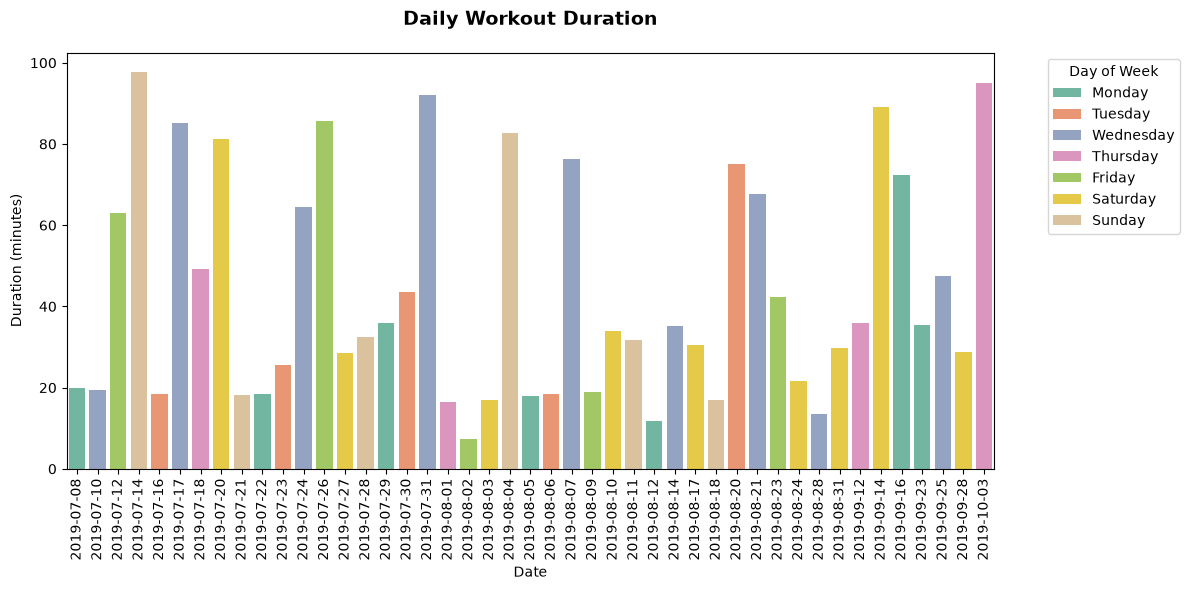

In [48]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=duration_df, 
    x='date', 
    y='daily_duration(m)',
    hue='day_of_week',
    hue_order = day_order,
    palette='Set2'
)

plt.title('Daily Workout Duration', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Date')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=90)
plt.legend(title='Day of Week', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()  

There are 14 days with 60 minutes or longer workout:
- 1 Monday
- 1 Tuesday 
- 4 Wednesday
- 1 Thursday
- 2 Friday
- 2 Saturday
- 2 Sunday

While our client might pull a longer workout any day of the week, they tend to exercise longer most consistently on Wednesday.

### 3.5. Heart rate vs geographic coordinates 3D scatter plot

Next, we will create a 3D scatter plot to visualize the relationship between heart rate and geographic coordinates.

Text(0.5, 0, 'Altitude')

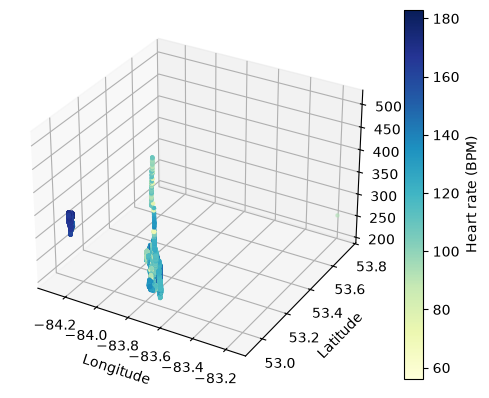

In [52]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

artists = ax.scatter(
    df_selected['position_long'], 
    df_selected['position_lat'], 
    df_selected['unified_altitude'], 
    s = 5,
    c = df_selected['heart_rate'],
    cmap = 'YlGnBu'
)

plt.colorbar(artists).set_label('Heart rate (BPM)')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Altitude')

# We'll make this chart animated. So we can see better details of this chart from different angles.

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Now we define an initializeation function which will render the initial image, and return a set of Artists
# to render
def init():
    ax.scatter(df_selected['position_long'], df_selected['position_lat'], df_selected['unified_altitude'])
    return ax.get_children()

def update_view(frame):
    ax.view_init(30, frame)
    return ax.get_children()

from matplotlib import animation

anim = animation.FuncAnimation(
    fig,
    update_view,
    init_func = init,
    frames = [x for x in range(0, 360, 3)],
    interval = 20
)

from IPython.display import HTML
HTML(anim.to_jshtml())